In [3]:
from pathlib import Path

DATA_DIR  = Path('path_to_kaggle_preprocessed_dataset')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR  = DATA_DIR / 'test'
NOISE_DIR = DATA_DIR / '_background_noise_'

print("Train:", len(list(TRAIN_DIR.rglob('*.wav'))))
print("Valid:", len(list(VALID_DIR.rglob('*.wav'))))


Train: 51486
Valid: 6828


In [4]:
import sys, os
REPO_PATH = 'path_to_repo'
sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH) 

from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
import torch
from models.cnn import CNN
from models.train import train, predict
import models.evaluate
from models.evaluate import evaluate
from plots import plot_training_curves, plot_confusion_matrix, plot_per_class_metrics

import importlib
importlib.reload(sys.modules['models.train'])
importlib.reload(models.evaluate)

from models.train import train, predict
from models.evaluate import evaluate

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: cuda


In [5]:
train_ds, valid_ds, test_ds = get_datasets('mfcc', train_path=TRAIN_DIR, valid_path=VALID_DIR, test_path=TEST_DIR)

In [7]:
precompute_features(train_ds, Path('/kaggle/working/cache/train'))
precompute_features(valid_ds, Path('/kaggle/working/cache/valid'))
precompute_features(test_ds,  Path('/kaggle/working/cache/test'))

train_ds_cached = CachedDataset('/kaggle/working/cache/train')
valid_ds_cached = CachedDataset('/kaggle/working/cache/valid')
test_ds_cached  = CachedDataset('/kaggle/working/cache/test')

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache/train


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache/valid


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache/test


In [ ]:
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)

In [15]:
cnn = CNN(num_classes=12).to(device)
total_params = sum(p.numel() for p in cnn.parameters())
print(f'Parameters: {total_params:,}')

Parameters: 94,668


In [16]:
model, history = train(cnn, train_ds_cached, valid_ds_cached,
                       epochs=30, batch_size=64, lr=3e-4, device=device,
                       checkpoint_name='/kaggle/working/checkpoints/cnn_mfcc')

Epoch 1/30 | Train Loss: 1.2724 | Valid Loss: 1.0435 | Valid Acc: 0.6504 | Valid Macro F1: 0.2389
  -> saved (val_acc=0.6504)
Epoch 2/30 | Train Loss: 0.8868 | Valid Loss: 0.8815 | Valid Acc: 0.6813 | Valid Macro F1: 0.3223
  -> saved (val_acc=0.6813)
Epoch 3/30 | Train Loss: 0.6891 | Valid Loss: 0.8952 | Valid Acc: 0.7354 | Valid Macro F1: 0.6482
  -> saved (val_acc=0.7354)
Epoch 4/30 | Train Loss: 0.5826 | Valid Loss: 0.5821 | Valid Acc: 0.8143 | Valid Macro F1: 0.6713
  -> saved (val_acc=0.8143)
Epoch 5/30 | Train Loss: 0.5084 | Valid Loss: 0.5756 | Valid Acc: 0.7916 | Valid Macro F1: 0.6325
Epoch 6/30 | Train Loss: 0.4611 | Valid Loss: 0.5017 | Valid Acc: 0.8512 | Valid Macro F1: 0.7549
  -> saved (val_acc=0.8512)
Epoch 7/30 | Train Loss: 0.4235 | Valid Loss: 0.4229 | Valid Acc: 0.8767 | Valid Macro F1: 0.8041
  -> saved (val_acc=0.8767)
Epoch 8/30 | Train Loss: 0.3886 | Valid Loss: 0.5154 | Valid Acc: 0.8355 | Valid Macro F1: 0.7515
Epoch 9/30 | Train Loss: 0.3668 | Valid Loss: 0.

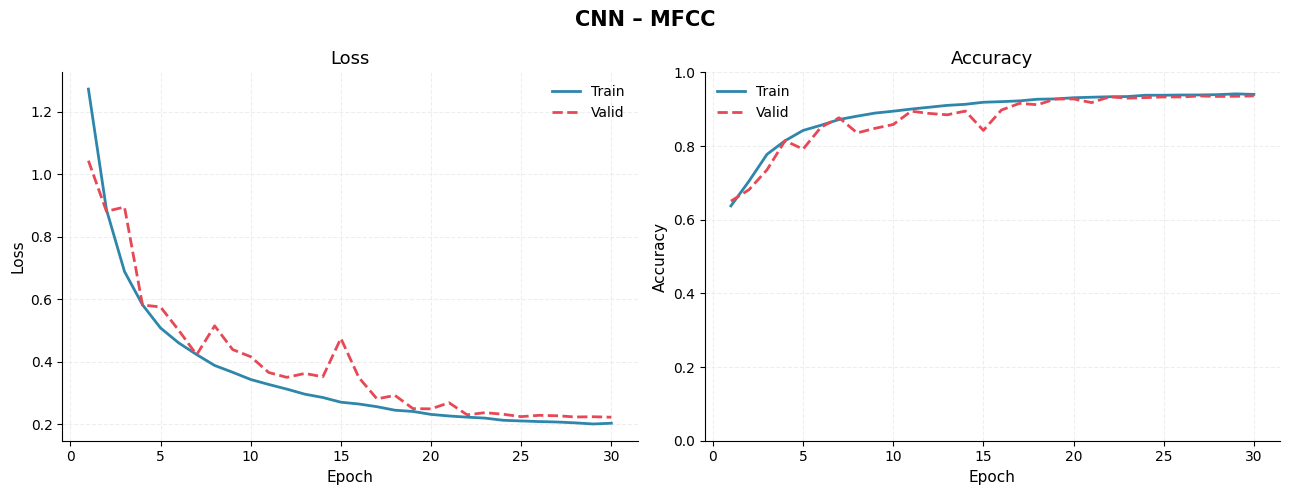

In [17]:
plot_training_curves(history, title='CNN – MFCC')


Accuracy: 0.9360
Macro F1: 0.9065
Weighted F1: 0.9348

Per-class report:
              precision    recall  f1-score   support

        down       0.96      0.79      0.86       264
          go       0.90      0.73      0.80       260
        left       0.95      0.87      0.91       247
          no       0.82      0.85      0.84       270
         off       0.91      0.91      0.91       256
          on       0.95      0.84      0.89       257
       right       0.97      0.86      0.91       256
        stop       0.97      0.89      0.93       246
          up       0.94      0.89      0.91       260
         yes       0.96      0.93      0.95       261
     silence       1.00      1.00      1.00        30
     unknown       0.94      0.98      0.96      4221

    accuracy                           0.94      6828
   macro avg       0.94      0.88      0.91      6828
weighted avg       0.94      0.94      0.93      6828



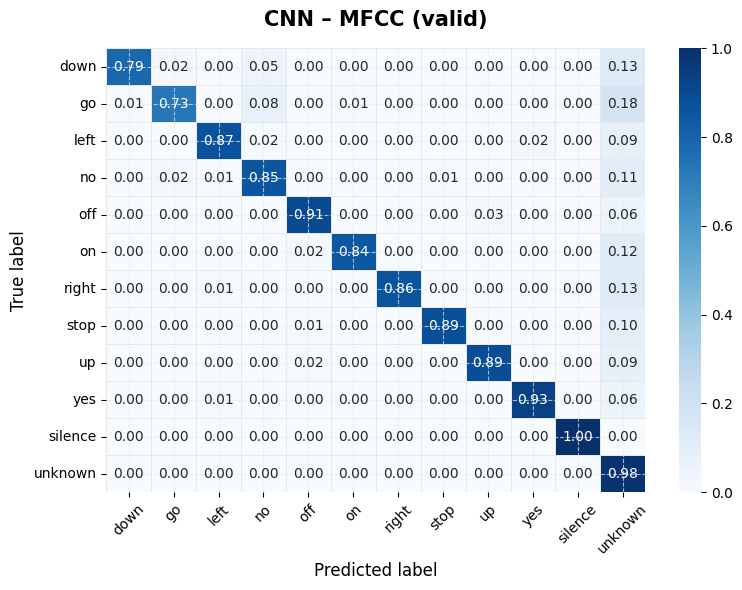

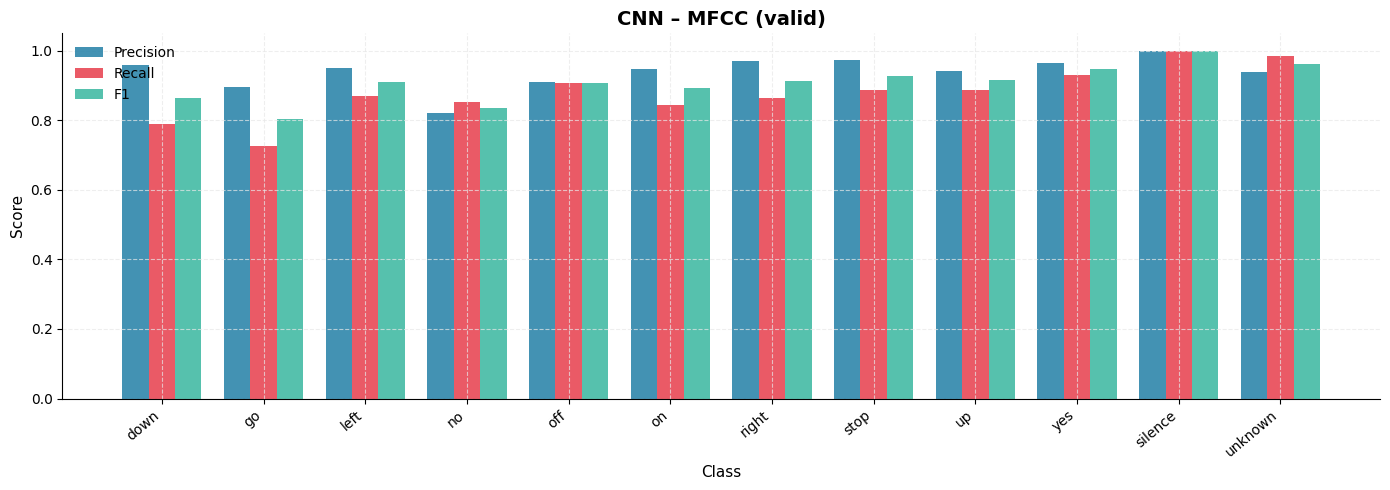

In [18]:
preds_valid, labels_valid = predict(model, valid_ds_cached, device=device)
result_valid = evaluate(preds_valid, labels_valid)
plot_confusion_matrix(result_valid['cm'], normalize=True, title='CNN – MFCC (valid)')
plot_per_class_metrics(labels_valid.numpy(), preds_valid.numpy(), title='CNN – MFCC (valid)')


Accuracy: 0.9337
Macro F1: 0.8995
Weighted F1: 0.9327

Per-class report:
              precision    recall  f1-score   support

        down       0.94      0.75      0.83       253
          go       0.79      0.77      0.78       251
        left       0.88      0.88      0.88       267
          no       0.86      0.83      0.85       252
         off       0.92      0.89      0.91       262
          on       0.97      0.90      0.93       246
       right       0.96      0.82      0.88       259
        stop       0.98      0.91      0.94       249
          up       0.93      0.90      0.91       272
         yes       0.96      0.91      0.93       256
     silence       1.00      0.97      0.98        30
     unknown       0.94      0.98      0.96      4268

    accuracy                           0.93      6865
   macro avg       0.93      0.87      0.90      6865
weighted avg       0.93      0.93      0.93      6865



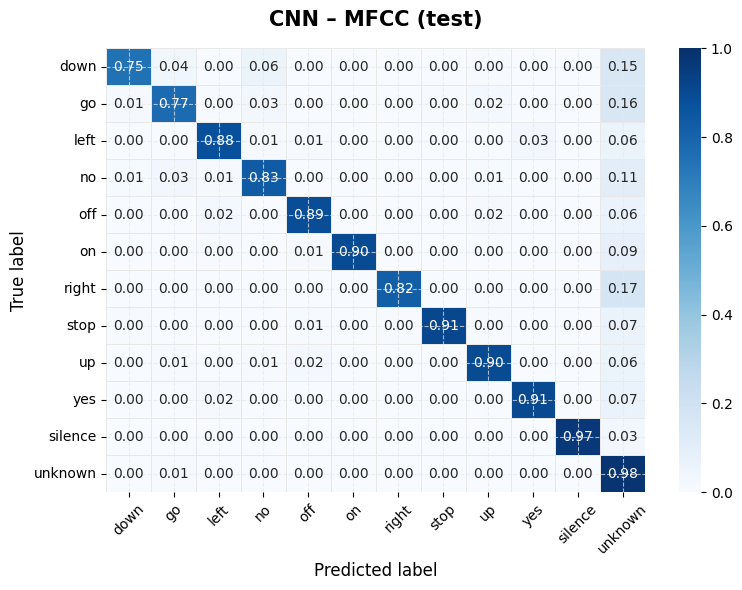

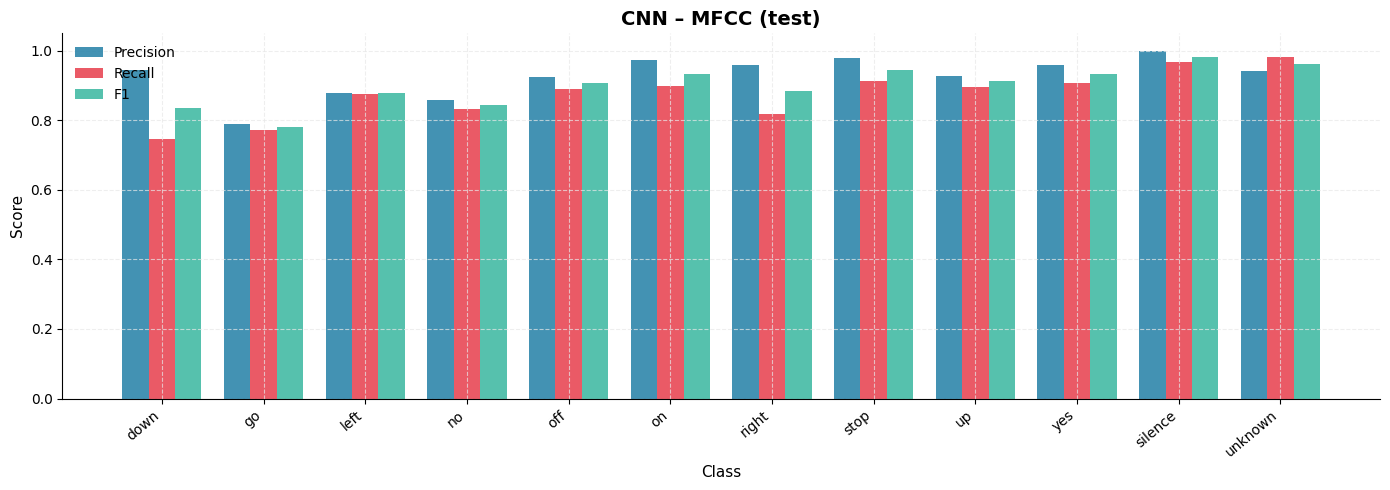

In [19]:
preds_test, labels_test = predict(model, test_ds_cached, device=device)
result_test = evaluate(preds_test, labels_test)
plot_confusion_matrix(result_test['cm'], normalize=True, title='CNN – MFCC (test)')
plot_per_class_metrics(labels_test.numpy(), preds_test.numpy(), title='CNN – MFCC (test)')